# Actividad: semillas de trigo — las 7 pautas

Dataset: **210 granos de trigo** de **3 variedades** (Kama, Rosa y Canadiense), 70 de cada una, con **7 medidas** del grano (UCI «seeds»). En el enunciado las columnas se llaman *Area, Perimeter, …, Class*; acá están en español: `área`, `perímetro`, `compacidad`, `largo_grano`, `ancho_grano`, `coef_asimetría`, `largo_surco` y la variable objetivo `clase`.

Cada pauta tiene su enunciado, el código, el resultado y una conclusión.

In [1]:
import math
from pathlib import Path

import matplotlib
matplotlib.use("Agg")  # guarda los gráficos en archivos, sin abrir ventanas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

CARPETA = Path.cwd()
DATOS = CARPETA / "datos" / "semillas.csv"
RESULTADOS = CARPETA / "resultados"
OBJETIVO = "clase"
COLORES = {"Kama": "#ff5c8a", "Rosa": "#3dc7ff", "Canadiense": "#2fe0a1"}


def titulo(texto):
    print("\n" + "=" * 78 + f"\n{texto}\n" + "=" * 78)



from IPython.display import Image, display
RESULTADOS.mkdir(exist_ok=True)

## Pauta 1

> Cargar y explorar el dataset con Pandas. Identificar sus 7 características y verificar valores nulos.

In [2]:
def pauta_1():
    titulo("PAUTA 1 · Cargar y explorar el dataset con Pandas")
    datos = pd.read_csv(DATOS)
    print(f"Forma del dataset: {datos.shape[0]} filas × {datos.shape[1]} columnas\n")
    print("Primeras filas:")
    print(datos.head().to_string())
    caracteristicas = [c for c in datos.columns if c != OBJETIVO]
    print(f"\nLas {len(caracteristicas)} características: {', '.join(caracteristicas)}")
    print("\nTipos de dato:")
    print(datos.dtypes.to_string())
    print("\nValores nulos por columna:")
    nulos = datos.isnull().sum()
    print(nulos.to_string())
    print(f"Total de valores nulos: {int(nulos.sum())}")
    print("\nGranos por variedad:")
    print(datos[OBJETIVO].value_counts().to_string())
    print("\nResumen estadístico (describe):")
    print(datos.describe().round(3).to_string())
    print("\nConclusión: el dataset tiene 210 granos y 7 características numéricas, no tiene valores "
          "nulos y está equilibrado (70 granos de cada variedad).")
    return datos


datos = pauta_1()


PAUTA 1 · Cargar y explorar el dataset con Pandas
Forma del dataset: 210 filas × 8 columnas

Primeras filas:
    área  perímetro  compacidad  largo_grano  ancho_grano  coef_asimetría  largo_surco clase
0  15.26      14.84      0.8710        5.763        3.312           2.221        5.220  Kama
1  14.88      14.57      0.8811        5.554        3.333           1.018        4.956  Kama
2  14.29      14.09      0.9050        5.291        3.337           2.699        4.825  Kama
3  13.84      13.94      0.8955        5.324        3.379           2.259        4.805  Kama
4  16.14      14.99      0.9034        5.658        3.562           1.355        5.175  Kama

Las 7 características: área, perímetro, compacidad, largo_grano, ancho_grano, coef_asimetría, largo_surco

Tipos de dato:
área              float64
perímetro         float64
compacidad        float64
largo_grano       float64
ancho_grano       float64
coef_asimetría    float64
largo_surco       float64
clase                 str



## Pauta 2

> Separar las características predictoras de la variable `clase` y aplicar normalización con StandardScaler.

In [3]:
def pauta_2(datos):
    titulo("PAUTA 2 · Separar la variable objetivo y normalizar con StandardScaler")
    X = datos.drop(columns=[OBJETIVO])
    y = datos[OBJETIVO]
    print(f"X (características): {X.shape}   y (variedad): {y.shape}")
    escalador = StandardScaler()
    X_normalizado = pd.DataFrame(escalador.fit_transform(X), columns=X.columns)
    comparacion = pd.DataFrame({
        "media antes": X.mean(), "desviación antes": X.std(ddof=0),
        "media después": X_normalizado.mean().round(6), "desviación después": X_normalizado.std(ddof=0),
    }).round(3)
    print("\nAntes y después de StandardScaler (media 0 y desviación 1 en todas):")
    print(comparacion.to_string())
    comparacion.to_csv(RESULTADOS / "pauta2_normalizacion.csv", encoding="utf-8-sig")
    print("\nConclusión: después de normalizar, todas las características quedan con media 0 y "
          "desviación 1, así ninguna pesa más que otra al entrenar (importante para K-Vecinos, que "
          "compara distancias).")
    return X, y, X_normalizado


X, y, X_normalizado = pauta_2(datos)


PAUTA 2 · Separar la variable objetivo y normalizar con StandardScaler
X (características): (210, 7)   y (variedad): (210,)



Antes y después de StandardScaler (media 0 y desviación 1 en todas):
                media antes  desviación antes  media después  desviación después
área                 14.848             2.903           -0.0                 1.0
perímetro            14.559             1.303            0.0                 1.0
compacidad            0.871             0.024            0.0                 1.0
largo_grano           5.629             0.442           -0.0                 1.0
ancho_grano           3.259             0.377           -0.0                 1.0
coef_asimetría        3.700             1.500           -0.0                 1.0
largo_surco           5.408             0.490           -0.0                 1.0



Conclusión: después de normalizar, todas las características quedan con media 0 y desviación 1, así ninguna pesa más que otra al entrenar (importante para K-Vecinos, que compara distancias).


## Pauta 3

> Utilizar NumPy para trabajar con vectores y matrices, calcular producto punto, norma y resolver un sistema de ecuaciones.

In [4]:
def pauta_3(datos):
    titulo("PAUTA 3 · NumPy: vectores, matrices, producto punto, norma y sistema de ecuaciones")
    columnas = ["área", "perímetro", "compacidad"]
    v1 = datos.loc[0, columnas].to_numpy(dtype=float)
    v2 = datos.loc[1, columnas].to_numpy(dtype=float)
    print(f"v1 (grano 1) = {v1}\nv2 (grano 2) = {v2}")
    print(f"v1 + v2 = {v1 + v2}")
    print(f"v1 - v2 = {v1 - v2}")
    print(f"3 · v1 = {3 * v1}")
    producto_punto = np.dot(v1, v2)
    print(f"Producto punto v1 · v2 (np.dot) = {producto_punto:.4f}")
    print(f"Norma de v1 (np.linalg.norm) = {np.linalg.norm(v1):.4f}")
    print(f"Norma de v2 = {np.linalg.norm(v2):.4f}")
    print(f"Distancia entre v1 y v2 = {np.linalg.norm(v1 - v2):.4f}  (la que usa K-Vecinos)")

    A = datos.loc[0:2, columnas].to_numpy(dtype=float)   # matriz 3×3: 3 granos × 3 medidas
    print(f"\nMatriz A (granos 1 a 3):\n{A}")
    print(f"Transpuesta de A:\n{A.T}")
    print(f"A × Aᵀ (np.dot):\n{np.dot(A, A.T).round(3)}")

    # Sistema A · w = b: qué pesos combinan área, perímetro y compacidad para dar el largo del grano.
    b = datos.loc[0:2, "largo_grano"].to_numpy(dtype=float)
    w = np.linalg.solve(A, b)
    print(f"\nSistema A · w = b, con b = largo_grano = {b}")
    print(f"Solución (np.linalg.solve): w = {w.round(4)}")
    print(f"Verificación A · w = {np.dot(A, w).round(4)}  (igual a b)")
    print("\nConclusión: cada grano es un vector con sus medidas; el producto punto, la norma y la "
          "distancia se calculan con NumPy, y el sistema se resolvió con np.linalg.solve (al "
          "multiplicar A por la solución se vuelve a obtener b).")


pauta_3(datos)


PAUTA 3 · NumPy: vectores, matrices, producto punto, norma y sistema de ecuaciones
v1 (grano 1) = [15.26  14.84   0.871]
v2 (grano 2) = [14.88   14.57    0.8811]
v1 + v2 = [30.14   29.41    1.7521]
v1 - v2 = [ 0.38    0.27   -0.0101]
3 · v1 = [45.78  44.52   2.613]
Producto punto v1 · v2 (np.dot) = 444.0550
Norma de v1 (np.linalg.norm) = 21.3038
Norma de v2 = 20.8441
Distancia entre v1 y v2 = 0.4663  (la que usa K-Vecinos)

Matriz A (granos 1 a 3):
[[15.26   14.84    0.871 ]
 [14.88   14.57    0.8811]
 [14.29   14.09    0.905 ]]
Transpuesta de A:
[[15.26   14.88   14.29  ]
 [14.84   14.57   14.09  ]
 [ 0.871   0.8811  0.905 ]]
A × Aᵀ (np.dot):
[[453.852 444.055 427.949]
 [444.055 434.476 418.724]
 [427.949 418.724 403.551]]

Sistema A · w = b, con b = largo_grano = [5.763 5.554 5.291]
Solución (np.linalg.solve): w = [ 1.2148 -0.9065  0.7782]
Verificación A · w = [5.763 5.554 5.291]  (igual a b)

Conclusión: cada grano es un vector con sus medidas; el producto punto, la norma y la dist

## Pauta 4

> Calcular media, mediana, varianza y desviación estándar de las variables área y perímetro. Implementar manualmente la varianza y desviación estándar de área y comparar con NumPy.

In [5]:
def varianza_manual(valores):
    """Varianza poblacional a mano: promedio de (x − media)², sin np.var()."""
    n = len(valores)
    media = sum(valores) / n
    return sum((x - media) ** 2 for x in valores) / n


def desviacion_manual(valores):
    """Desviación estándar a mano: raíz cuadrada de la varianza manual, sin np.std()."""
    return math.sqrt(varianza_manual(valores))


def pauta_4(datos):
    titulo("PAUTA 4 · Media, mediana, varianza y desviación de área y perímetro")
    filas = []
    for columna in ["área", "perímetro"]:
        valores = datos[columna].to_numpy(dtype=float)
        filas.append({
            "variable": columna,
            "media": np.mean(valores),
            "mediana": np.median(valores),
            "varianza NumPy": np.var(valores),
            "desviación NumPy": np.std(valores),
            "varianza manual": varianza_manual(list(valores)),
            "desviación manual": desviacion_manual(list(valores)),
        })
    tabla = pd.DataFrame(filas).set_index("variable")
    tabla["diferencia varianza"] = (tabla["varianza NumPy"] - tabla["varianza manual"]).abs()
    print(tabla.round(4).to_string())
    tabla.round(6).to_csv(RESULTADOS / "pauta4_estadistica.csv", encoding="utf-8-sig")
    a = tabla.loc["área"]
    print(f"\nConclusión: la media de área ({a['media']:.2f}) es mayor que su mediana "
          f"({a['mediana']:.2f}): hay algunos granos grandes que tiran el promedio para arriba. La "
          "varianza y la desviación de área calculadas a mano dan exactamente lo mismo que NumPy "
          f"(diferencia {a['diferencia varianza']:.2e}). Área varía más que perímetro.")


pauta_4(datos)


PAUTA 4 · Media, mediana, varianza y desviación de área y perímetro
             media  mediana  varianza NumPy  desviación NumPy  varianza manual  desviación manual  diferencia varianza
variable                                                                                                              
área       14.8475   14.355          8.4260            2.9028           8.4260             2.9028                  0.0
perímetro  14.5593   14.320          1.6974            1.3028           1.6974             1.3028                  0.0

Conclusión: la media de área (14.85) es mayor que su mediana (14.36): hay algunos granos grandes que tiran el promedio para arriba. La varianza y la desviación de área calculadas a mano dan exactamente lo mismo que NumPy (diferencia 1.78e-15). Área varía más que perímetro.


## Pauta 5

> Identificar valores atípicos en área utilizando el criterio de dos desviaciones estándar.

In [6]:
def pauta_5(datos):
    titulo("PAUTA 5 · Valores atípicos de área (media ± 2 desviaciones estándar)")
    area = datos["área"]
    media, desviacion = area.mean(), area.std(ddof=0)
    inferior, superior = media - 2 * desviacion, media + 2 * desviacion
    atipicos = datos[(area < inferior) | (area > superior)]
    print(f"Media = {media:.3f}   desviación = {desviacion:.3f}")
    print(f"Límite inferior (media − 2σ) = {inferior:.3f}")
    print(f"Límite superior (media + 2σ) = {superior:.3f}")
    print(f"\nGranos atípicos: {len(atipicos)} de {len(datos)}")
    print(atipicos[["área", "perímetro", OBJETIVO]].to_string())
    atipicos.to_csv(RESULTADOS / "pauta5_atipicos.csv", encoding="utf-8-sig")
    print(f"\nConclusión: {len(atipicos)} granos ({len(atipicos) / len(datos):.1%}) quedan fuera del "
          "rango, todos por encima: son granos muy grandes (de la variedad Rosa), no errores de medición.")
    return inferior, superior


inferior, superior = pauta_5(datos)


PAUTA 5 · Valores atípicos de área (media ± 2 desviaciones estándar)
Media = 14.848   desviación = 2.903
Límite inferior (media − 2σ) = 9.042
Límite superior (media + 2σ) = 20.653

Granos atípicos: 4 de 210
      área  perímetro clase
77   20.71      17.23  Rosa
88   21.18      17.21  Rosa
89   20.88      17.05  Rosa
114  20.97      17.25  Rosa

Conclusión: 4 granos (1.9%) quedan fuera del rango, todos por encima: son granos muy grandes (de la variedad Rosa), no errores de medición.


## Pauta 6

> Generar un histograma de área y un gráfico de dispersión de área contra perímetro, diferenciando las tres variedades.


PAUTA 6 · Histograma de área y dispersión área contra perímetro


Gráficos guardados en resultados/: pauta6_histograma_area.png y pauta6_dispersion_area_perimetro.png
Correlación entre área y perímetro: 0.994
             área  perímetro
clase                       
Canadiense  11.87      13.25
Kama        14.33      14.29
Rosa        18.33      16.14

Conclusión: área y perímetro van casi juntos. En la dispersión las 3 variedades forman grupos separados: los granos de Rosa son los más grandes, los de Canadiense los más chicos y los de Kama quedan en el medio.


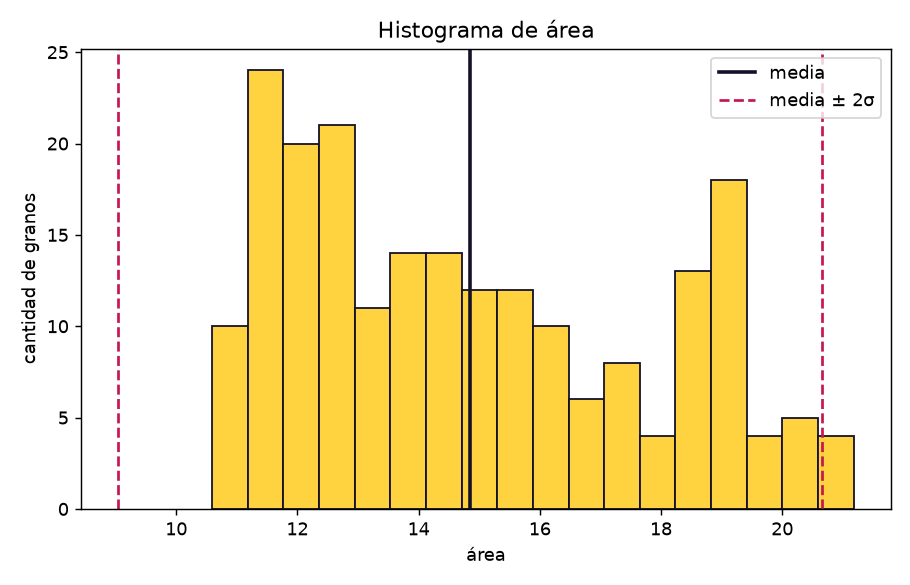

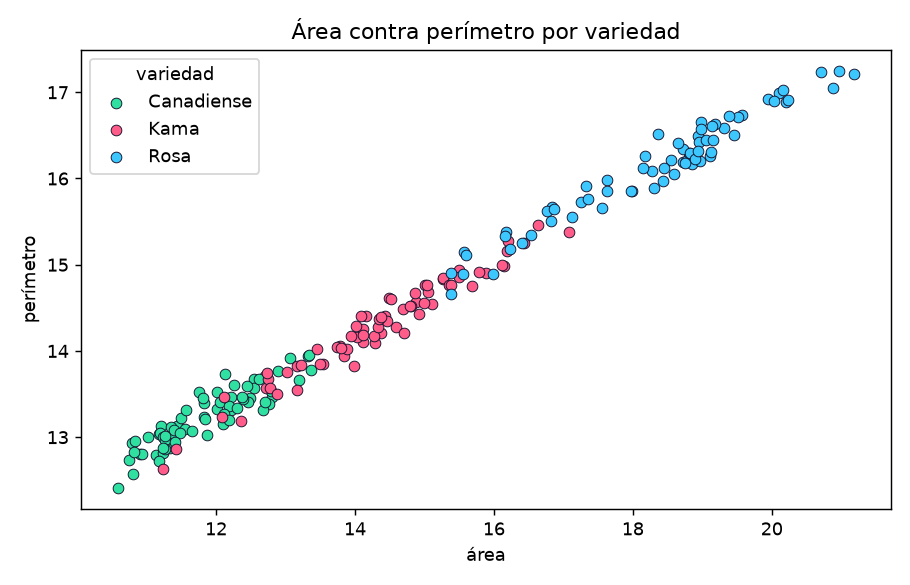

In [7]:
def pauta_6(datos, inferior, superior):
    titulo("PAUTA 6 · Histograma de área y dispersión área contra perímetro")
    figura, eje = plt.subplots(figsize=(7, 4.5))
    eje.hist(datos["área"], bins=18, color="#ffd23f", edgecolor="#14112b")
    eje.axvline(datos["área"].mean(), color="#14112b", linewidth=2, label="media")
    eje.axvline(inferior, color="#c4174f", linestyle="--", label="media ± 2σ")
    eje.axvline(superior, color="#c4174f", linestyle="--")
    eje.set(title="Histograma de área", xlabel="área", ylabel="cantidad de granos")
    eje.legend()
    figura.tight_layout()
    figura.savefig(RESULTADOS / "pauta6_histograma_area.png", dpi=130)
    plt.close(figura)

    figura, eje = plt.subplots(figsize=(7, 4.5))
    for variedad, grupo in datos.groupby(OBJETIVO):
        eje.scatter(grupo["área"], grupo["perímetro"], label=variedad, color=COLORES[variedad],
                    edgecolors="#14112b", linewidths=0.5, s=35)
    eje.set(title="Área contra perímetro por variedad", xlabel="área", ylabel="perímetro")
    eje.legend(title="variedad")
    figura.tight_layout()
    figura.savefig(RESULTADOS / "pauta6_dispersion_area_perimetro.png", dpi=130)
    plt.close(figura)
    correlacion = datos["área"].corr(datos["perímetro"])
    print("Gráficos guardados en resultados/: pauta6_histograma_area.png y "
          "pauta6_dispersion_area_perimetro.png")
    print(f"Correlación entre área y perímetro: {correlacion:.3f}")
    print(datos.groupby(OBJETIVO)[["área", "perímetro"]].mean().round(2).to_string())
    print("\nConclusión: área y perímetro van casi juntos. En la dispersión las 3 variedades forman "
          "grupos separados: los granos de Rosa son los más grandes, los de Canadiense los más chicos "
          "y los de Kama quedan en el medio.")


pauta_6(datos, inferior, superior)
display(Image(filename=str(RESULTADOS / 'pauta6_histograma_area.png')))
display(Image(filename=str(RESULTADOS / 'pauta6_dispersion_area_perimetro.png')))

## Pauta 7

> Entrenar y comparar dos modelos de clasificación: K-Vecinos (KNeighborsClassifier) y Árbol de Decisión (DecisionTreeClassifier). Evaluar ambos mediante Accuracy y comparar sus resultados.


PAUTA 7 · K-Vecinos contra Árbol de Decisión (Accuracy)
K-Vecinos (KNeighborsClassifier): Accuracy = 0.9048  (90.48%)
Árbol de Decisión (DecisionTreeClassifier): Accuracy = 0.9286  (92.86%)



Conclusión: gana Árbol de Decisión por 2.38%. Los dos aciertan alrededor de 9 de cada 10 granos del grupo de prueba, que no se usó para entrenar.


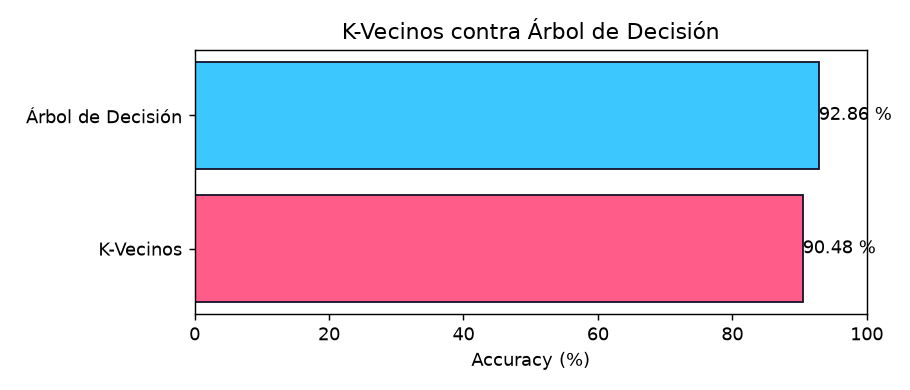

In [8]:
def pauta_7(X, y):
    titulo("PAUTA 7 · K-Vecinos contra Árbol de Decisión (Accuracy)")
    # 80 % para entrenar y 20 % para probar, con la misma proporción de cada variedad.
    X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    # El escalador aprende sólo de la parte de entrenamiento (así no se filtran datos de la prueba).
    escalador = StandardScaler().fit(X_entrena)
    X_entrena_n, X_prueba_n = escalador.transform(X_entrena), escalador.transform(X_prueba)
    modelos = {
        "K-Vecinos (KNeighborsClassifier)": KNeighborsClassifier(n_neighbors=5),
        "Árbol de Decisión (DecisionTreeClassifier)": DecisionTreeClassifier(random_state=42),
    }
    resultados = {}
    for nombre, modelo in modelos.items():
        modelo.fit(X_entrena_n, y_entrena)
        resultados[nombre] = accuracy_score(y_prueba, modelo.predict(X_prueba_n))
        print(f"{nombre}: Accuracy = {resultados[nombre]:.4f}  ({resultados[nombre]:.2%})")
    tabla = pd.Series(resultados, name="accuracy")
    tabla.to_csv(RESULTADOS / "pauta7_modelos.csv", encoding="utf-8-sig")

    figura, eje = plt.subplots(figsize=(7, 3))
    barras = eje.barh(["K-Vecinos", "Árbol de Decisión"], [v * 100 for v in resultados.values()],
                      color=["#ff5c8a", "#3dc7ff"], edgecolor="#14112b")
    eje.bar_label(barras, fmt="%.2f %%")
    eje.set(xlim=(0, 100), xlabel="Accuracy (%)", title="K-Vecinos contra Árbol de Decisión")
    figura.tight_layout()
    figura.savefig(RESULTADOS / "pauta7_comparacion_modelos.png", dpi=130)
    plt.close(figura)

    ganador = max(resultados, key=resultados.get)
    diferencia = abs(list(resultados.values())[0] - list(resultados.values())[1])
    if diferencia < 1e-9:
        print("\nConclusión: los dos modelos aciertan lo mismo.")
    else:
        print(f"\nConclusión: gana {ganador.split(' (')[0]} por {diferencia:.2%}. Los dos aciertan "
              "alrededor de 9 de cada 10 granos del grupo de prueba, que no se usó para entrenar.")
    return resultados


resultados = pauta_7(X, y)
display(Image(filename=str(RESULTADOS / 'pauta7_comparacion_modelos.png')))

## Conclusión general

In [9]:
print("El dataset está completo y equilibrado; área y perímetro separan bien las 3 variedades de trigo, "
      "y los dos modelos las clasifican con buen acierto: "
      + ", ".join(f"{n.split(' (')[0]} {v:.2%}" for n, v in resultados.items()) + ".")

El dataset está completo y equilibrado; área y perímetro separan bien las 3 variedades de trigo, y los dos modelos las clasifican con buen acierto: K-Vecinos 90.48%, Árbol de Decisión 92.86%.
